In [2]:
import importlib
import plots
import feature_mining

importlib.reload(plots)
importlib.reload(feature_mining)

import pandas as pd

from plots import *
from feature_mining import *

#### Load labeled dataset

In [3]:
df = pd.read_csv("../data/ait_ads/labeled_combined_ait.csv", low_memory=False)
df.columns

# make sure timestamps are datetime and sorted
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")

#### Set run name and min_support parameter

In [4]:
run_name="test"
output_dir = f"../plots/{run_name}"
os.makedirs(output_dir,exist_ok=True)
min_support=50

#### Normalize `category`

In [5]:
df["category_norm"] = df["category"].astype(str).str.split(" - ").str[0].str.strip()

In [6]:
df["category_norm"].value_counts()

category_norm
Suricata: Alert                                                              306635
IDS event.                                                                   295032
Multiple IDS alerts for same id.                                               7036
AMiner: New event type.                                                        5787
Multiple IDS events from same source ip.                                       2362
Apache: Attempt to access forbidden file or directory.                         2353
Multiple IDS alerts for same id (ignoring now this id).                        1465
First time this IDS alert is generated.                                         626
AMiner: New user_acct parameter combination in Audit logs.                      354
Apache: Attempt to access forbidden directory index.                            338
AMiner: New user_auth parameter combination in Audit logs.                      300
Multiple IDS events from same source ip (ignoring now this src

### Window based mining run (scenario local)

##### Token mining (transactional)

In [13]:
scorer_name = "split"
miner_name = "2-itemset"

In [14]:
scenario_rankings, scenario_attack_flags, scenario_memory = window_based_mining(
    df,
    scorer=split_metric_scorer(),
    counter=mine_itemset_counts,
    counter_kwargs={"k":2}
)

# scenario_rankings, scenario_attack_flags = window_based_mining(
#     df,
#     scorer=fp_contrast_scorer(alpha=0.5),
#     counter=mine_itemset_counts,
#     counter_kwargs={"k":3, "min_support": min_support}
# )

# scenario_rankings, scenario_attack_flags = window_based_mining(
#     df,
#     scorer=fp_contrast_scorer(alpha=0.5),
#     counter=mine_token_counts,
# )

Running mining for scenario santos....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Running mining for scenario fox....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Running mining for scenario wardbeck....


...

/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Running mining for scenario wilson....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


Running mining for scenario harrison....


/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:112: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start = start.floor(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:113: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end = end.ceil(align_to)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:115: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  win = pd.Timedelta(window_size)
/Users/annavisman/stack/TUDelft/thesis/msc-thesis/aact/util.py:116: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  step = pd.Timedelta(step_size)


{'mem_trace': [{'start': Timestamp('2022-01-15 00:00:00+0000', tz='UTC'), 'end': Timestamp('2022-01-15 12:00:00+0000', tz='UTC'), 'has_attack': False, 'coverage_active': ["cov::('wazuh:is_ids_alert=1', 'wazuh:proto=TCP')", "cov::('wazuh:ids_severity=3.0', 'wazuh:proto=TCP')", "cov::('wazuh:ids_severity=3.0', 'wazuh:is_ids_alert=1')", "cov::('wazuh:ids_category=Generic Protocol Command Decode', 'wazuh:is_ids_alert=1')", "cov::('wazuh:ids_category=Generic Protocol Command Decode', 'wazuh:proto=TCP')", "cov::('wazuh:ids_category=Generic Protocol Command Decode', 'wazuh:ids_severity=3.0')", "cov::('wazuh:is_ids_alert=1', 'wazuh:src_freq_bin=very_high')", "cov::('wazuh:proto=TCP', 'wazuh:src_freq_bin=very_high')", "cov::('wazuh:ids_severity=3.0', 'wazuh:src_freq_bin=very_high')", "cov::('wazuh:category_norm=Suricata: Alert', 'wazuh:groups_str=ids|suricata')", "cov::('wazuh:decoder=snort', 'wazuh:decoder_parent=snort')", "cov::('wazuh:category_norm=Suricata: Alert', 'wazuh:decoder=json')", "

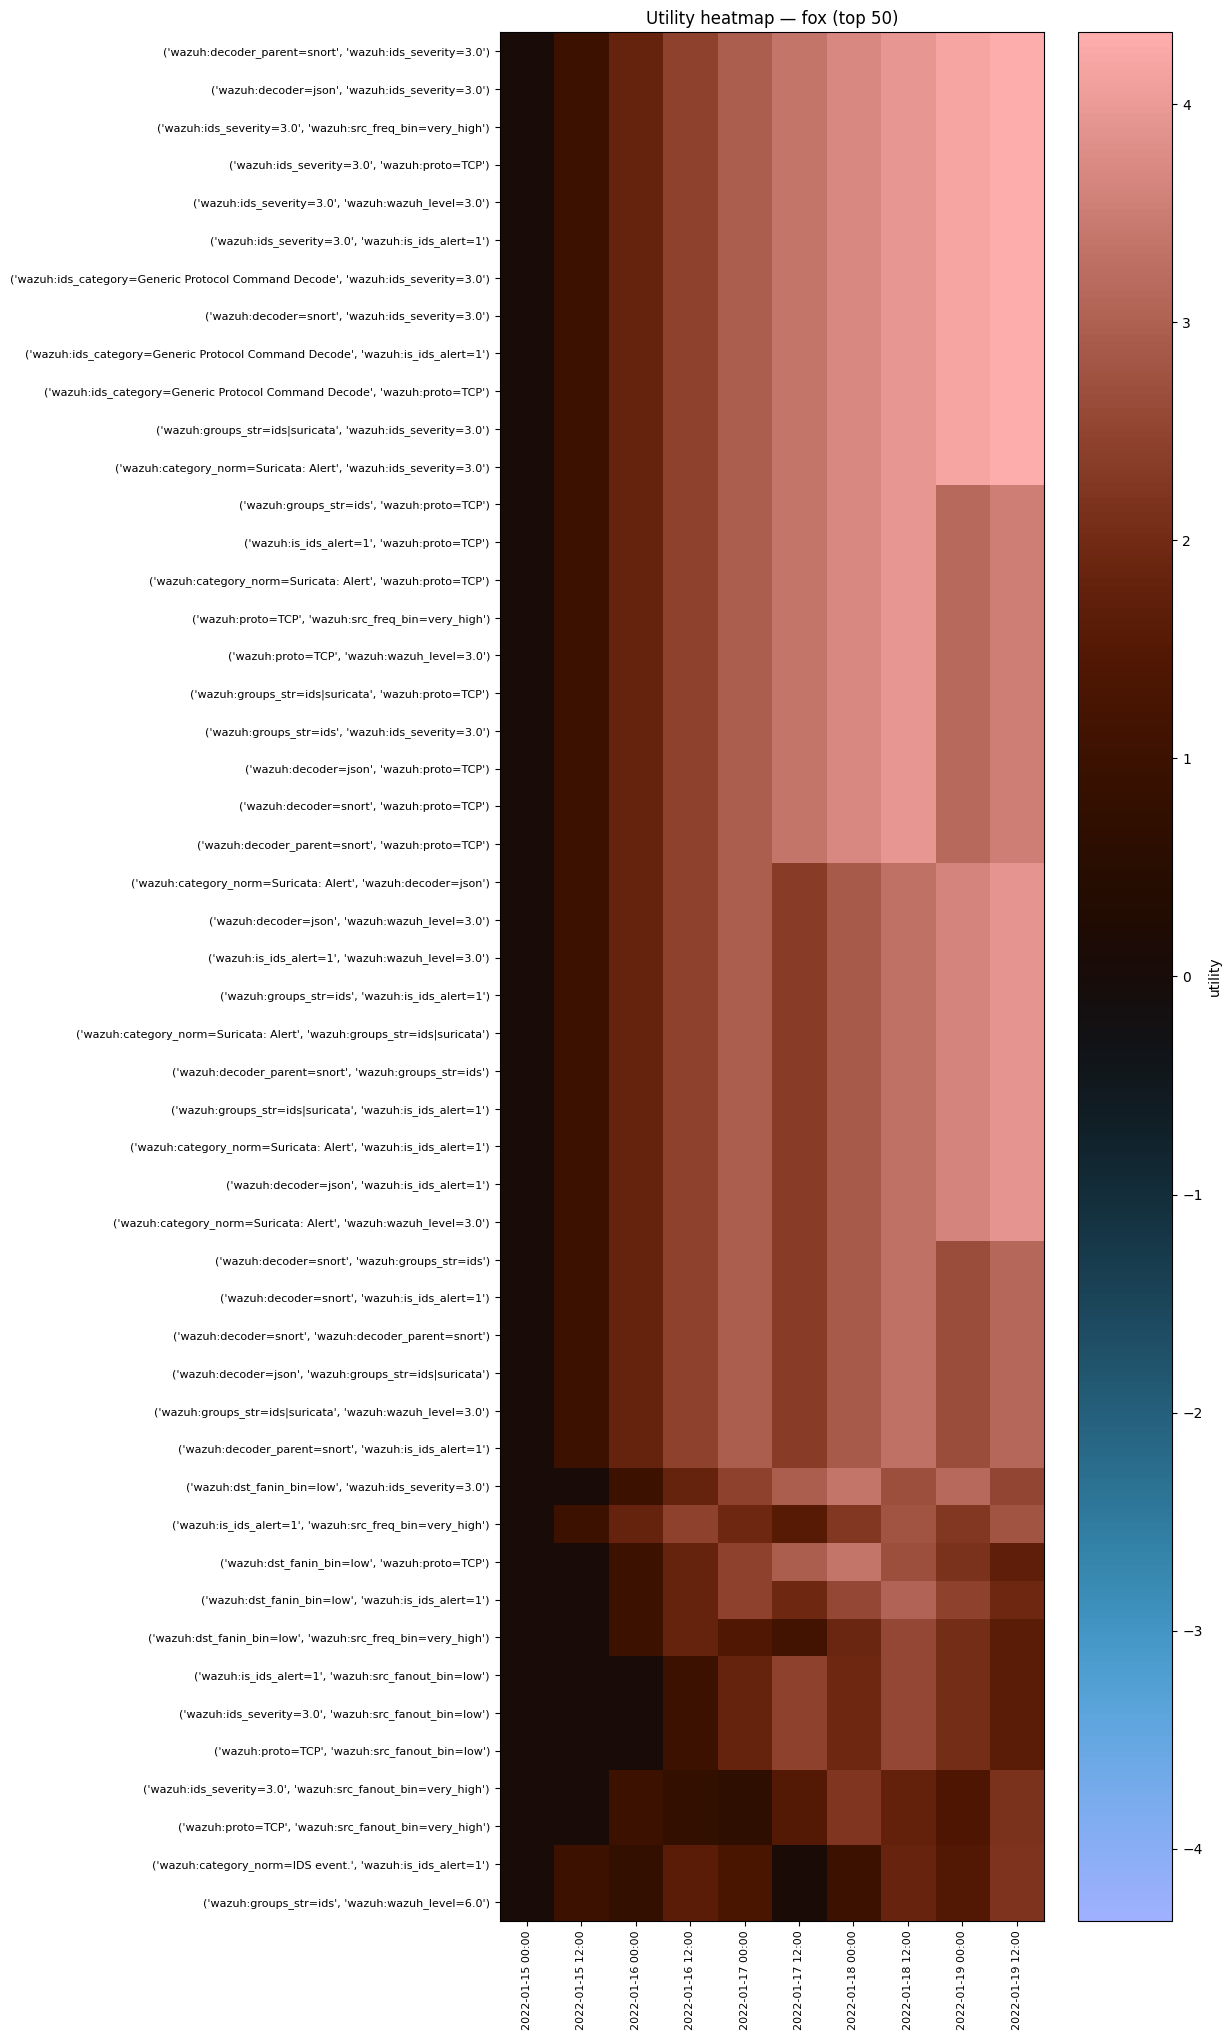

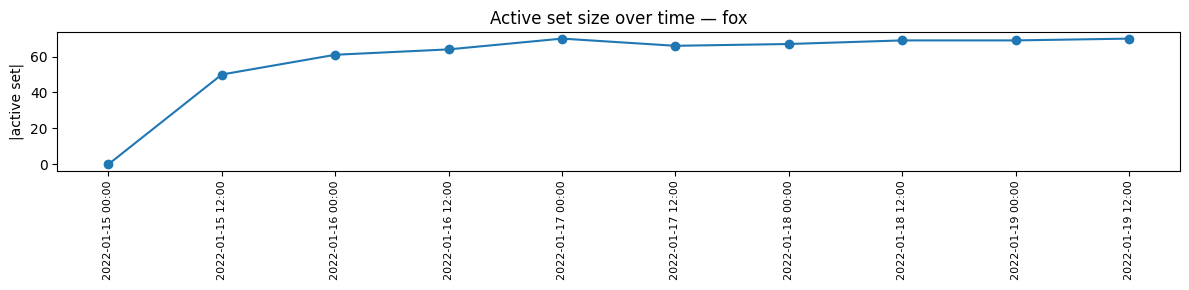

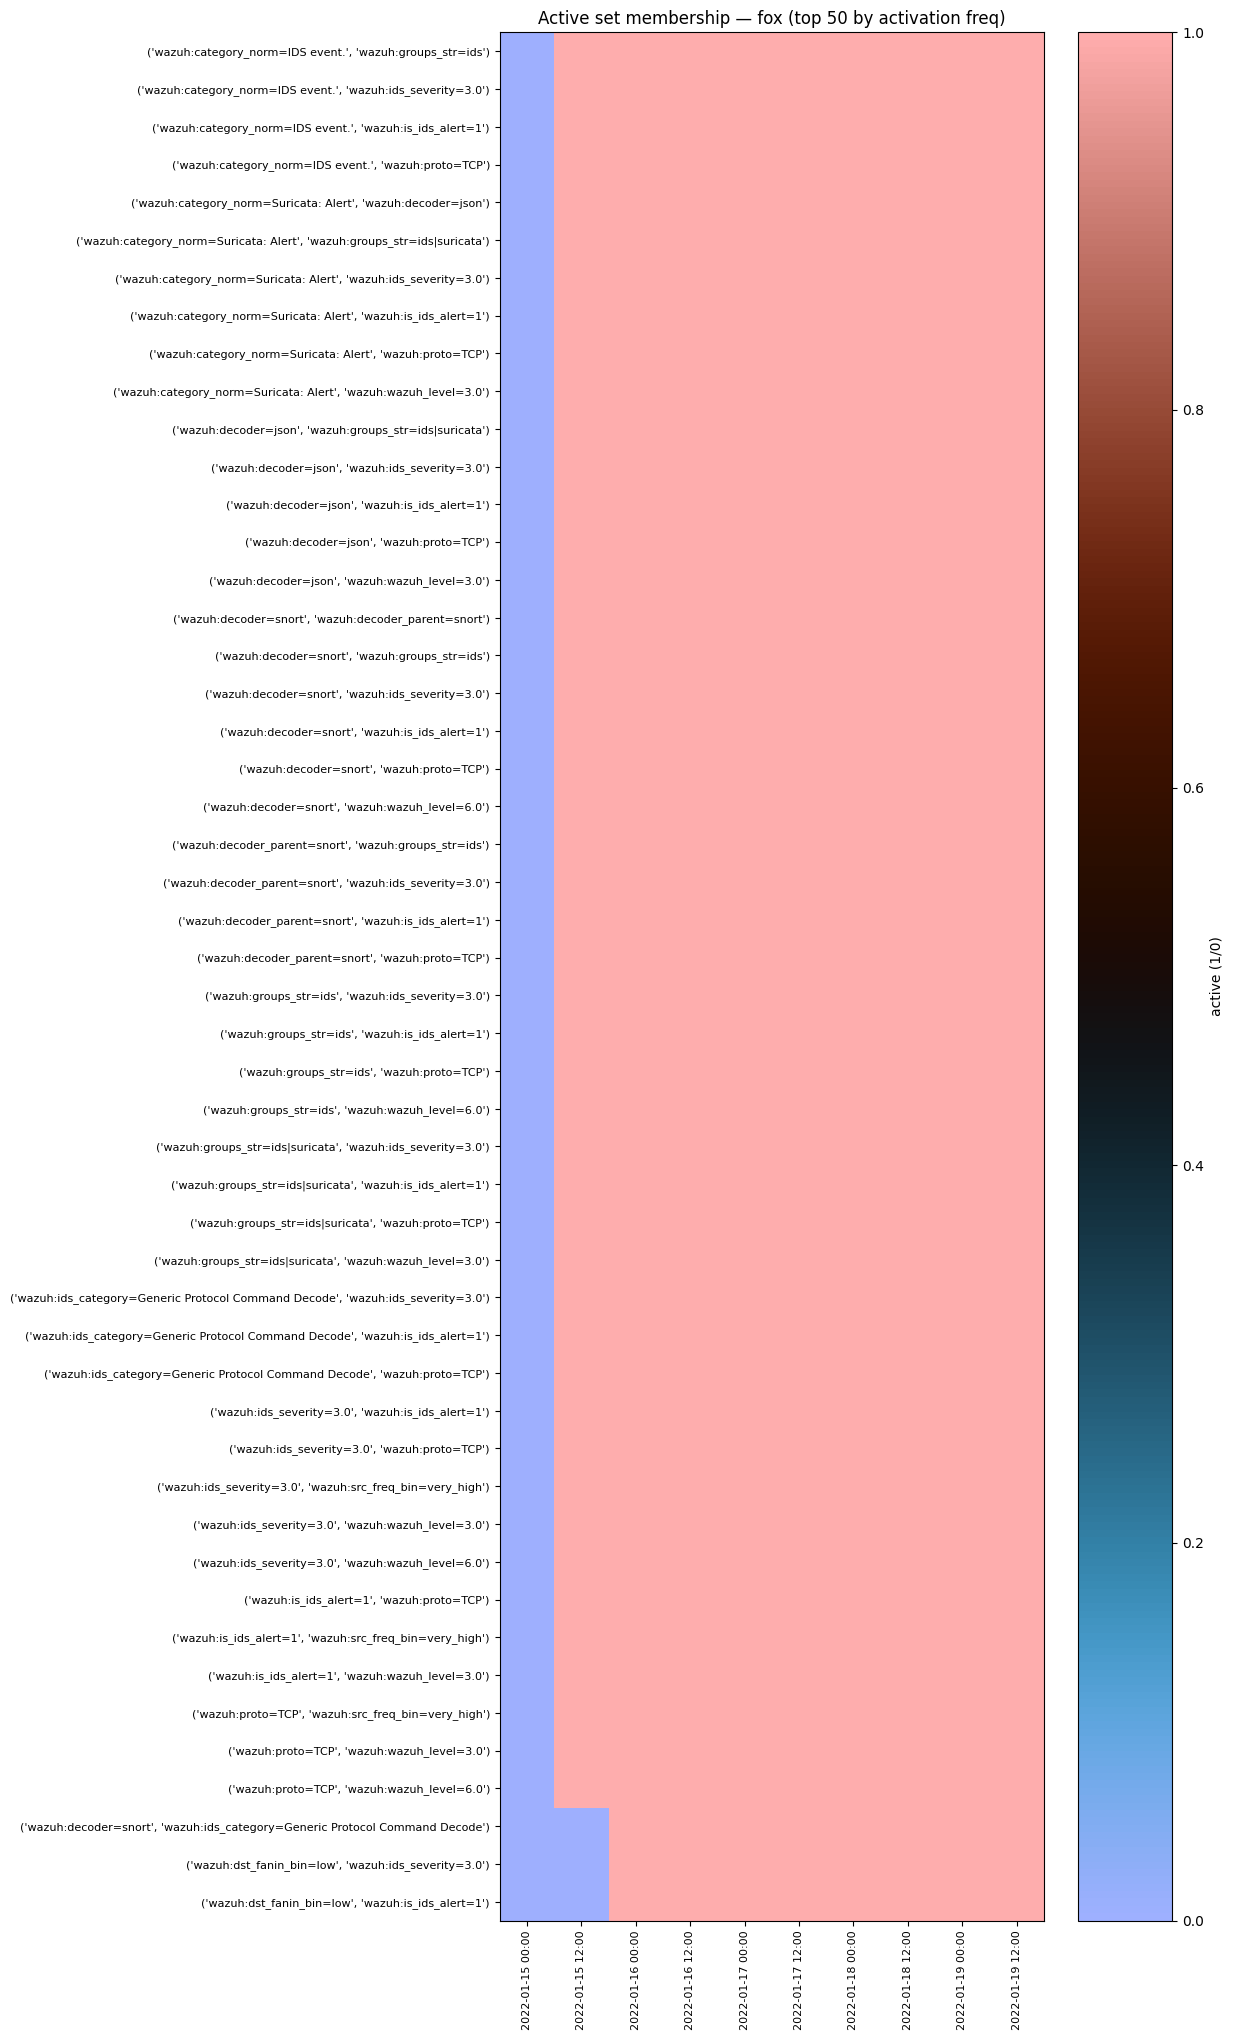

In [16]:
scenario = "fox"
entry = scenario_memory[scenario]  # one scenario key

print(entry)
plot_utility_heatmap(entry, scenario, output_dir=output_dir, top_n=50, fill_missing=None)
plot_active_set(entry, scenario,output_dir=output_dir,top_n_rows=50, show_counts=True)

#### Heat map for given scenario to show the contrast score of each token over all windows in the scenario

In [11]:
# find min and max global score so we can set a fixed colour scale for all scenario heatmaps
def compute_global_score_limits(scenario_rankings, score_col="score"):
    max_abs = 0.0
    for rankings in scenario_rankings.values():
        for ranking_k in rankings:
            if score_col in ranking_k.columns:
                max_abs = max(max_abs, np.abs(ranking_k[score_col]).max())
    return -max_abs, max_abs

vmin_global, vmax_global = compute_global_score_limits(scenario_rankings)
print(vmin_global, vmax_global)

-1.0 1.0


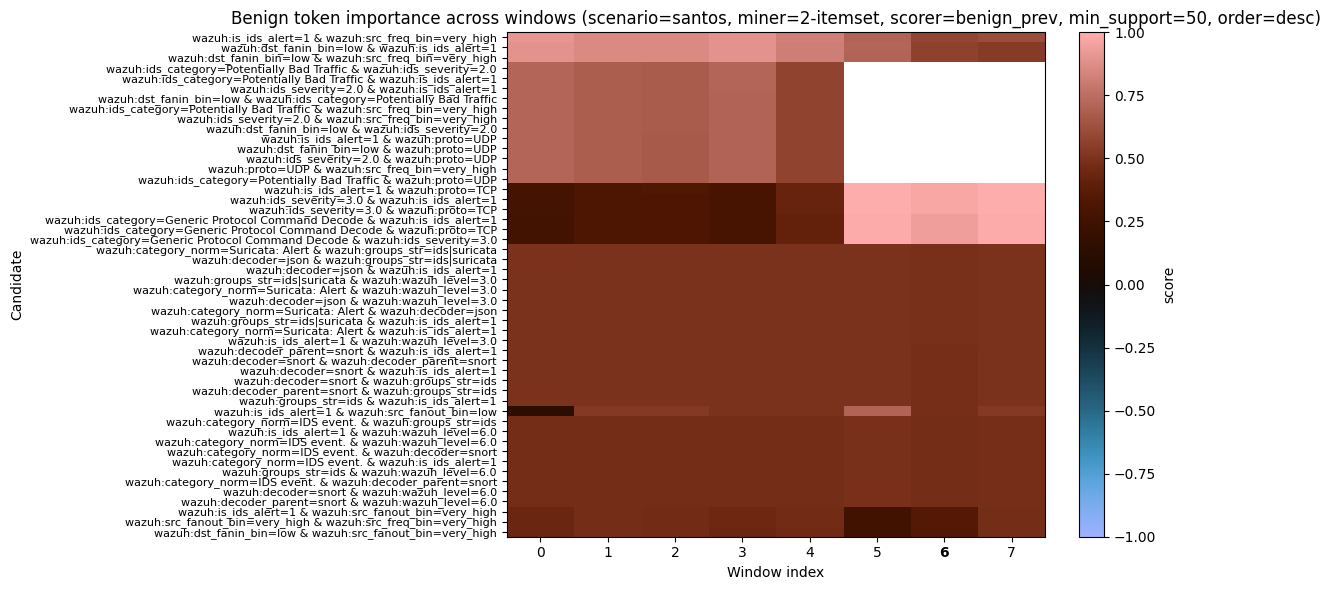

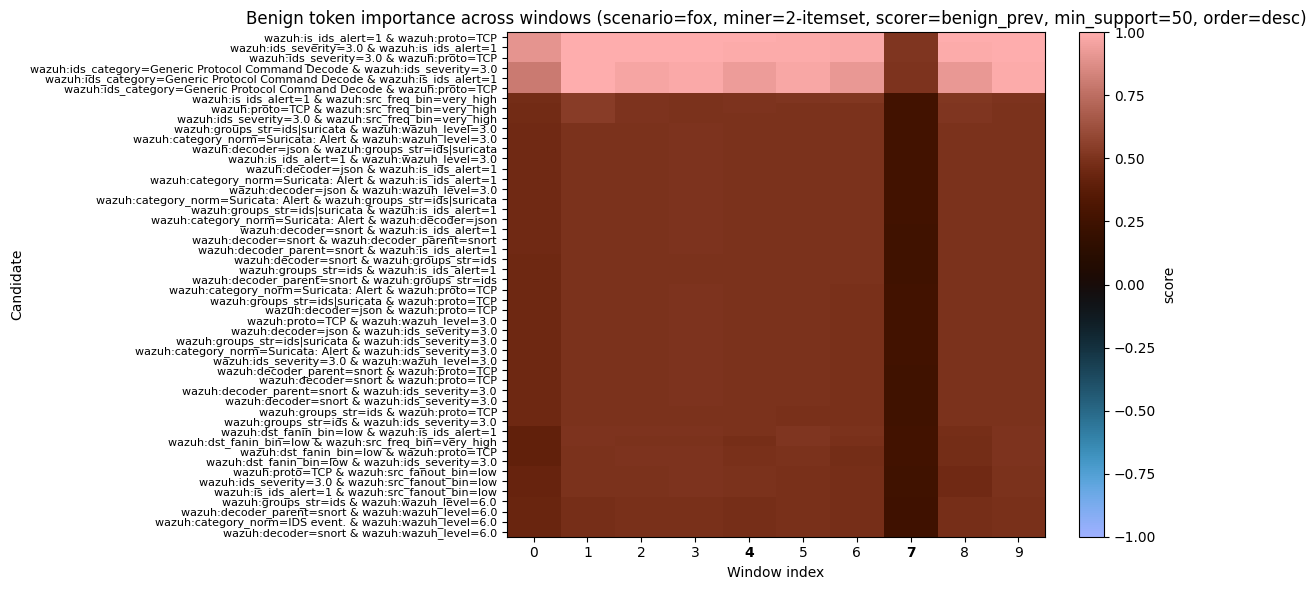

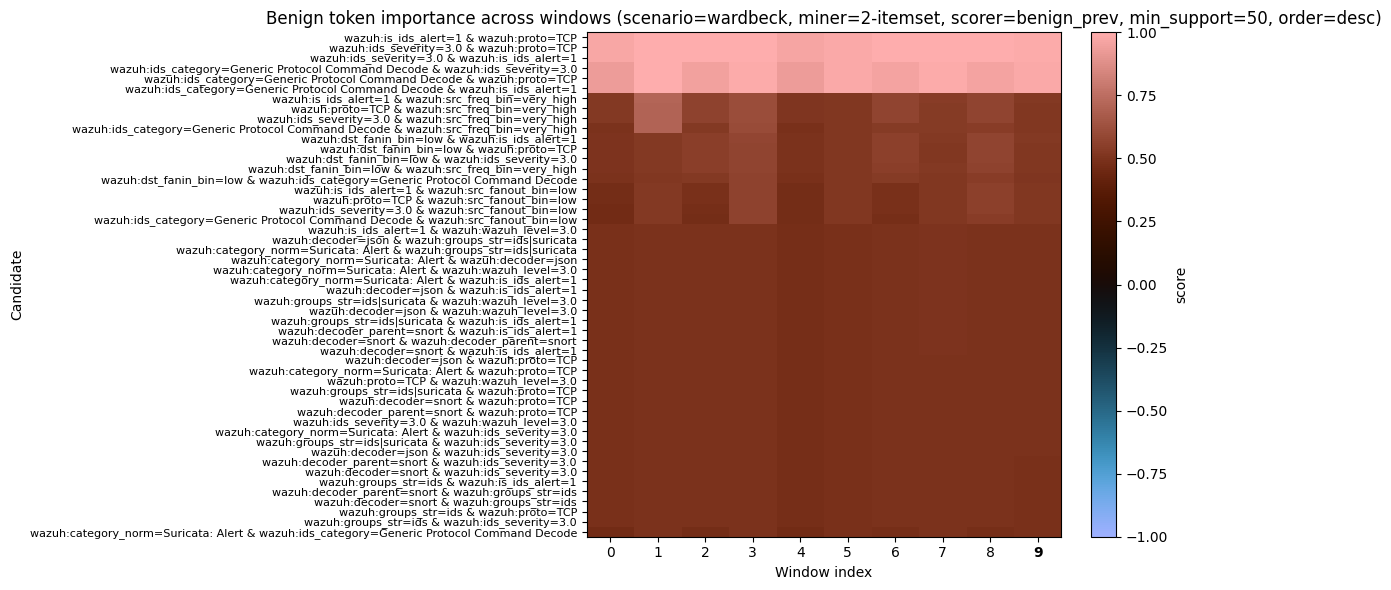

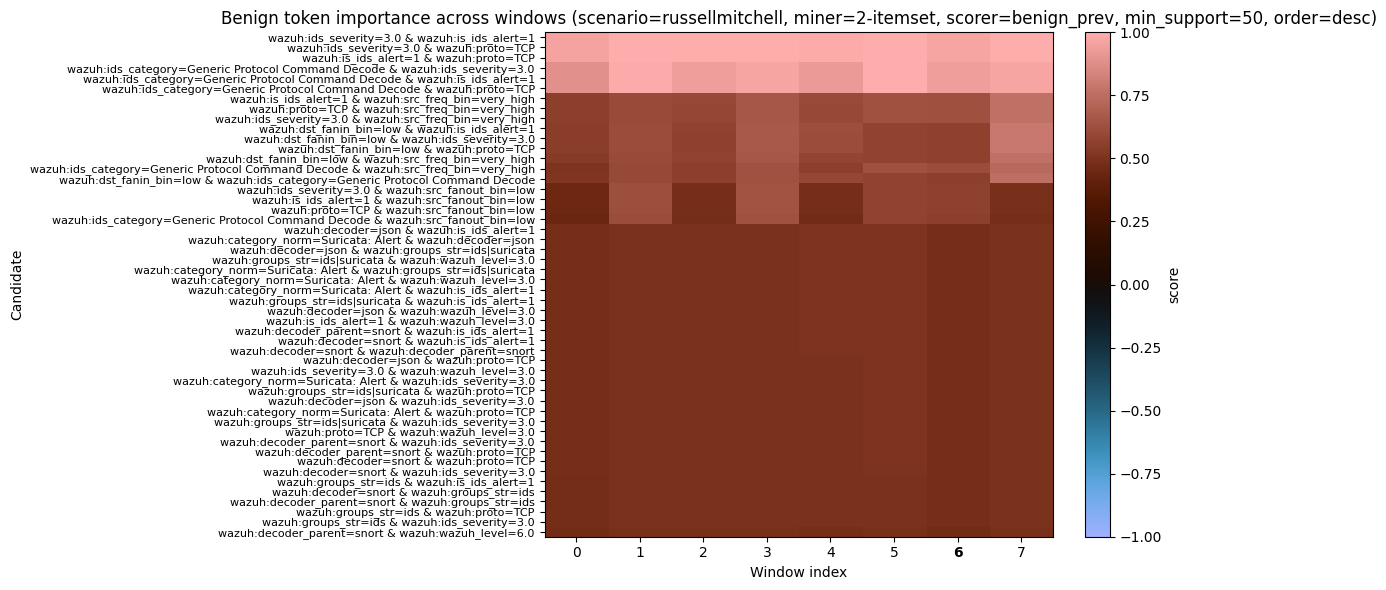

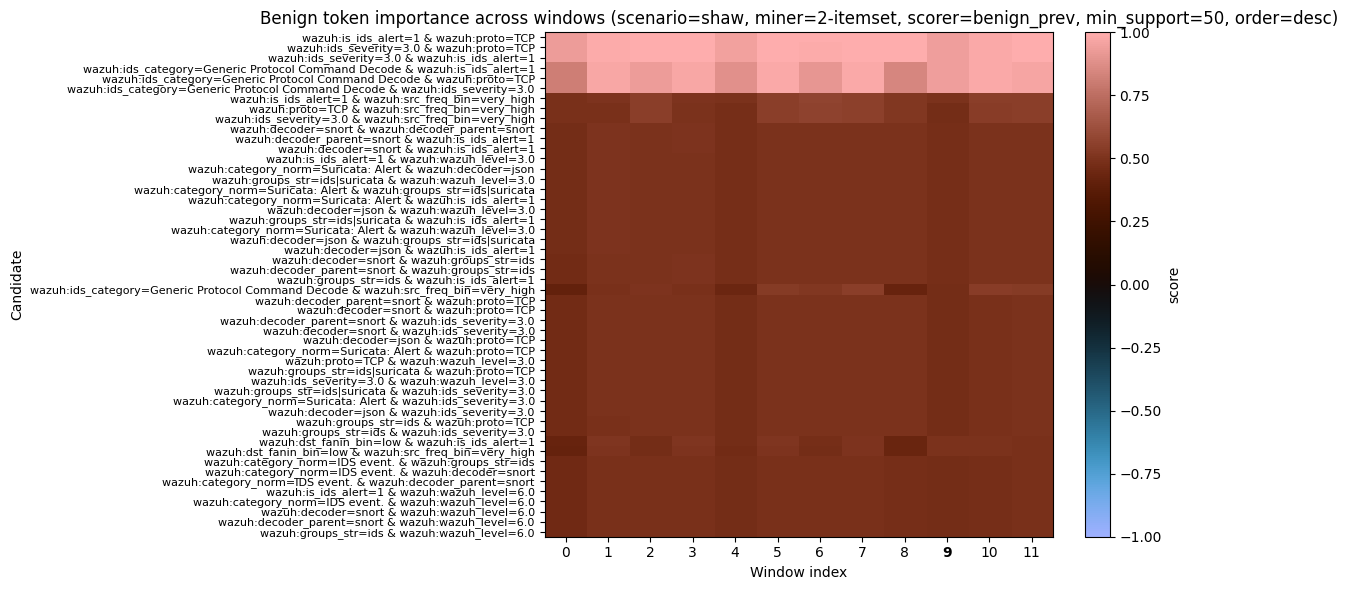

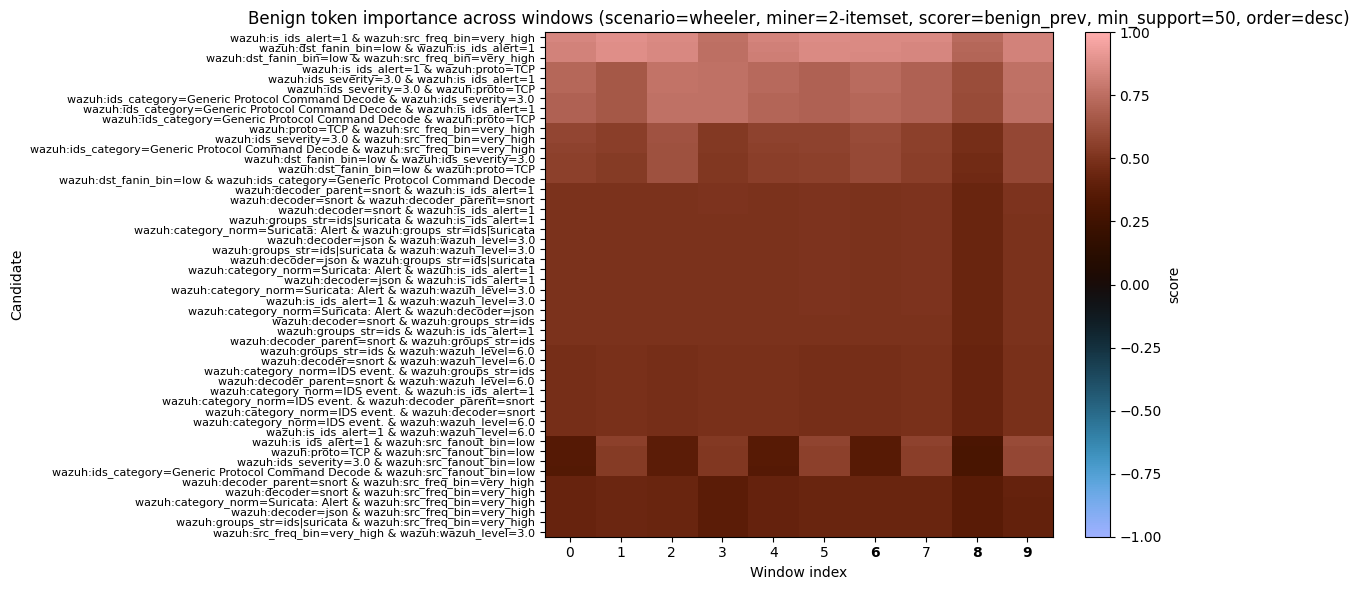

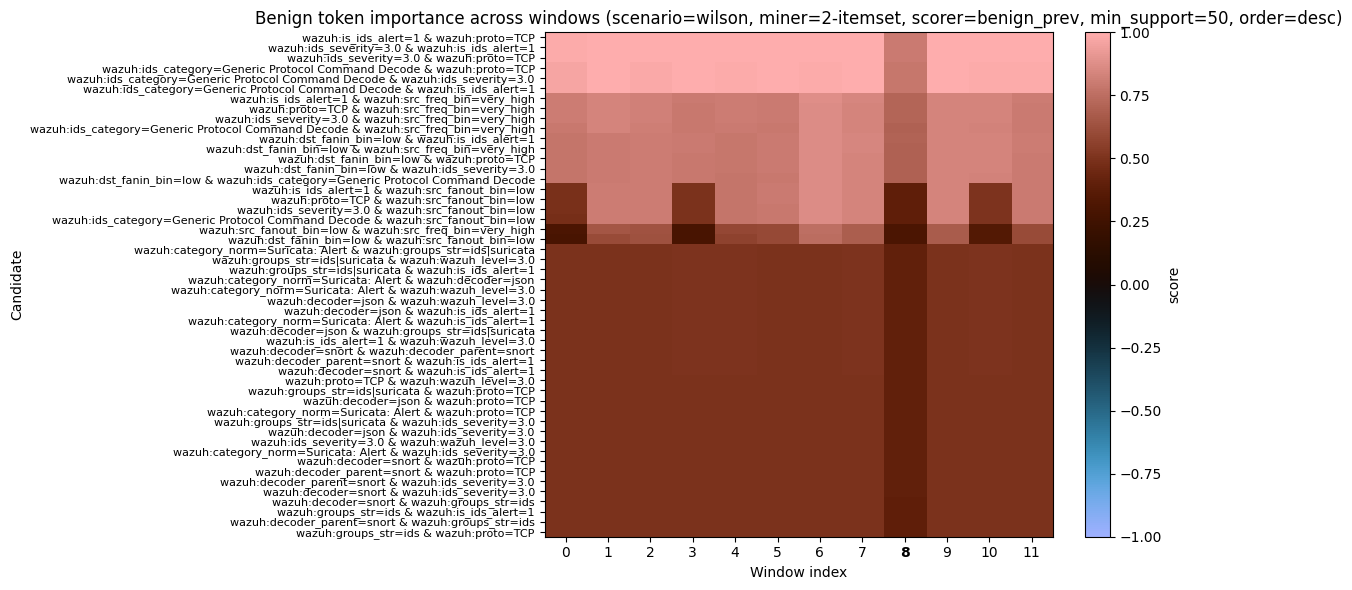

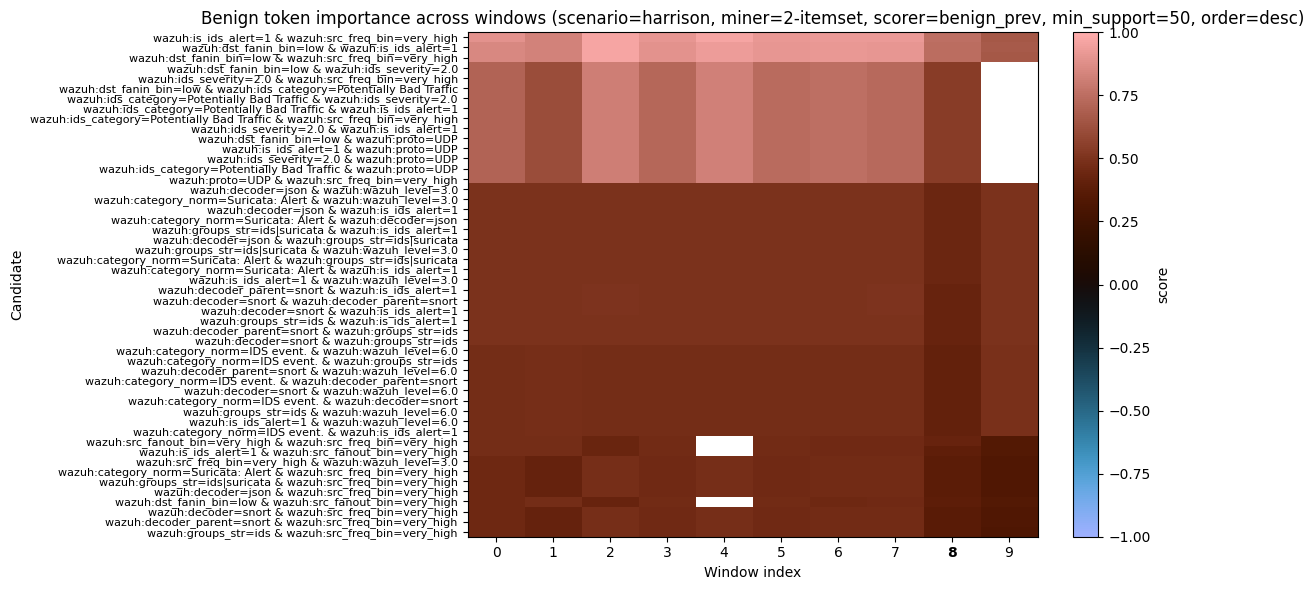

In [12]:
for scenario, df_s in df.groupby("scenario", sort=False):
    rankings = scenario_rankings.get(scenario)
    flags = scenario_attack_flags.get(scenario)
    plot_scenario_heatmap(rankings, flags, output_dir, scenario, miner_name, scorer_name, min_support, top_n=50, order="desc", vmin=vmin_global, vmax=vmax_global)